### Load relevant libraries

In [245]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, log_loss, accuracy_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

### Read in the data

In [246]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/March Madness 2026/2026 Data'
os.chdir(path)

In [247]:
df_all = pd.read_csv('dyad_matchups.csv', sep=',', index_col=None)
games_to_pred = pd.read_csv('games_to_predict.csv', sep=',', index_col=None)
team_a_stats = pd.read_csv('team_a_stats.csv', sep=',', index_col=None)
team_b_stats = pd.read_csv('team_b_stats.csv', sep=',', index_col=None)

### Prep the Data

In [248]:
# create a list including the desired explanatory variables
column_names = df_all.columns.values.tolist()

with pd.option_context('display.max_columns', None):
    print(df_all[column_names].head()), df_all[column_names].shape

   Season  team_a  team_b  team_a_win  top_a  mid_a  bot_a  intourney_a  \
0    2022    1231    1461           1      0      1      0          1.0   
1    2022    1394    1411           0      1      0      0          1.0   
2    2022    1323    1353           1      0      0      1          1.0   
3    2022    1136    1460           0      0      1      0          1.0   
4    2022    1116    1436           1      1      0      0          1.0   

   top_b  mid_b  bot_b  intourney_b  efg_diff   sa_diff   pt_diff  rank_diff  \
0      1      0      0          1.0  0.123279 -0.466673 -0.083709          3   
1      1      0      0          1.0 -0.223596  0.399081 -0.134725          0   
2      0      1      0          1.0  0.953422  0.732658  0.378520          4   
3      0      0      1          1.0 -1.008504  1.952189 -0.062424         -4   
4      1      0      0          1.0 -1.947198  0.317117 -0.739062          1   

   winsbefore_diff  winsafter_diff  clutch_diff  close_diff  grit_di

In [249]:
# Drop unnecessary variables: 
column_names = np.delete(column_names, [0, 1, 2, 3, 6, 7, 10, 11])

with pd.option_context('display.max_columns', None):
    print(df_all[column_names].head()), df_all[column_names].shape

   top_a  mid_a  top_b  mid_b  efg_diff   sa_diff   pt_diff  rank_diff  \
0      0      1      1      0  0.123279 -0.466673 -0.083709          3   
1      1      0      1      0 -0.223596  0.399081 -0.134725          0   
2      0      0      0      1  0.953422  0.732658  0.378520          4   
3      0      1      0      0 -1.008504  1.952189 -0.062424         -4   
4      1      0      1      0 -1.947198  0.317117 -0.739062          1   

   winsbefore_diff  winsafter_diff  clutch_diff  close_diff  grit_diff  \
0        -0.672530       -0.449176    -1.839140    0.211692  -2.412397   
1         0.472988       -0.661514     0.916100   -1.774185  -2.412397   
2        -0.174259        0.757985     0.864850   -0.686781   1.206199   
3         0.015918        0.898353     0.971621   -1.419348  -1.182384   
4         0.248319       -1.065773     0.000000    0.584674   2.412397   

   has_ot_diff  off_diff  def_diff  ast_diff   to_diff  stl_diff  blk_diff  \
0    -1.356835 -0.058910  0.0411

###### Dropped:
> ###### Season, team_a, team_b as these aren't predictors
> ###### team_a_win as this is our dependent variable
> ###### bot_a, bot_b to avoid multicollinearity
> ###### intourney_a, intourney_b since this is accounted for in winpercintourney

In [250]:
# Check for NaNs
print(df_all[column_names].isnull().sum())

# Set all NaN to 0
df_vars = df_all[column_names].fillna(0)

# Check for NaN's
# print(df_vars.isnull().sum())

top_a                    0
mid_a                    0
top_b                    0
mid_b                    0
efg_diff                 0
sa_diff                  0
pt_diff                  0
rank_diff                0
winsbefore_diff          0
winsafter_diff           0
clutch_diff              0
close_diff               0
grit_diff                0
has_ot_diff              0
off_diff                 0
def_diff                 0
ast_diff                 0
to_diff                  0
stl_diff                 0
blk_diff                 0
or_diff                  0
dr_diff                  0
3m_diff                  0
3a_diff                  0
seed_diff                0
conf_diff                0
winpercintourney_diff    0
dtype: int64


In [251]:
display(df_vars.head())

,top_a,mid_a,top_b,mid_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,seed_diff,conf_diff,winpercintourney_diff
0,0,1,1,0,0.123279,-0.466673,-0.083709,3,-0.672530,-0.449176,-1.839140,0.211692,-2.412397,-1.356835,-0.058910,0.041184,2.038143,0.307274,1.256320,2.806270,0.301169,-0.262428,-0.871038,-1.216128,0.0,6.0,0.500000
1,1,0,1,0,-0.223596,0.399081,-0.134725,0,0.472988,-0.661514,0.916100,-1.774185,-2.412397,-0.023727,0.684506,0.910136,1.404097,-0.153717,1.678516,-3.281965,0.311260,-1.045113,0.082365,0.127126,0.0,2.0,-0.500000
2,0,0,0,1,0.953422,0.732658,0.378520,4,-0.174259,0.757985,0.864850,-0.686781,1.206199,0.000000,0.608846,0.184594,-0.404406,-0.540938,-1.395293,-2.023982,-1.612410,1.011400,1.853222,1.517316,0.0,-3.0,0.666667
3,0,1,0,0,-1.008504,1.952189,-0.062424,-4,0.015918,0.898353,0.971621,-1.419348,-1.182384,1.426481,0.193547,0.287855,-0.221859,0.411605,0.371699,1.275345,0.822259,1.691796,1.233609,2.027859,0.0,-3.0,-0.500000
4,1,0,1,0,-1.947198,0.317117,-0.739062,1,0.248319,-1.065773,0.000000,0.584674,2.412397,1.269149,0.330585,1.284756,-0.487217,1.177091,1.619460,1.713927,2.150837,-0.307921,-1.512763,-0.816450,9.0,24.0,0.750000


### Recursive Feature Elimination with Cross Validation (RFECV)

In [252]:
### Define y and X
y = df_all['team_a_win'].astype(int)
X_orig = df_vars.copy()

# Build model
logreg = LogisticRegression(max_iter=500)

# Run RFECV
rfecv_orig = RFECV(estimator=logreg, cv=5, scoring='neg_log_loss')
rfecv_orig = rfecv_orig.fit(X_orig, y)

In [253]:
# Output selected features
print('Selected Features:')
print(X_orig.columns[rfecv_orig.support_])

print('\nFeature rankings:')
print(rfecv_orig.ranking_)

Selected Features:
Index(['top_a', 'mid_a', 'top_b', 'mid_b', 'efg_diff', 'sa_diff', 'pt_diff',
       'rank_diff', 'winsbefore_diff', 'winsafter_diff', 'clutch_diff',
       'close_diff', 'grit_diff', 'has_ot_diff', 'off_diff', 'def_diff',
       'ast_diff', 'to_diff', 'stl_diff', 'blk_diff', 'or_diff', 'dr_diff',
       '3m_diff', '3a_diff', 'seed_diff', 'conf_diff',
       'winpercintourney_diff'],
      dtype='object')

Feature rankings:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


##### All features were selected (all 1s in rankings), meaning each variable improved model performance under negative log loss scoring
##### However, this doesn't mean all features are equally important
##### Let's look at feature importance

In [254]:
# Absolute logistic regression coefficients (importance)
importance_orig = np.abs(rfecv_orig.estimator_.coef_[0])

# Associate with each feature
feature_importance_orig = list(zip(X_orig.columns, importance_orig))

# Sort by importance
feature_importance_orig_sorted = sorted(feature_importance_orig, key=lambda x: -x[1])

# Display
for feature, score in feature_importance_orig_sorted:
    print(f"{feature:25s} {score:.4f}")

winpercintourney_diff     0.7070
winsbefore_diff           0.4408
pt_diff                   0.4020
off_diff                  0.2621
def_diff                  0.1996
winsafter_diff            0.1956
top_a                     0.1440
clutch_diff               0.1439
top_b                     0.1402
conf_diff                 0.0973
mid_a                     0.0853
3m_diff                   0.0754
to_diff                   0.0711
efg_diff                  0.0639
3a_diff                   0.0528
mid_b                     0.0325
blk_diff                  0.0291
rank_diff                 0.0209
dr_diff                   0.0206
sa_diff                   0.0199
close_diff                0.0185
stl_diff                  0.0180
ast_diff                  0.0150
grit_diff                 0.0132
has_ot_diff               0.0106
seed_diff                 0.0049
or_diff                   0.0013


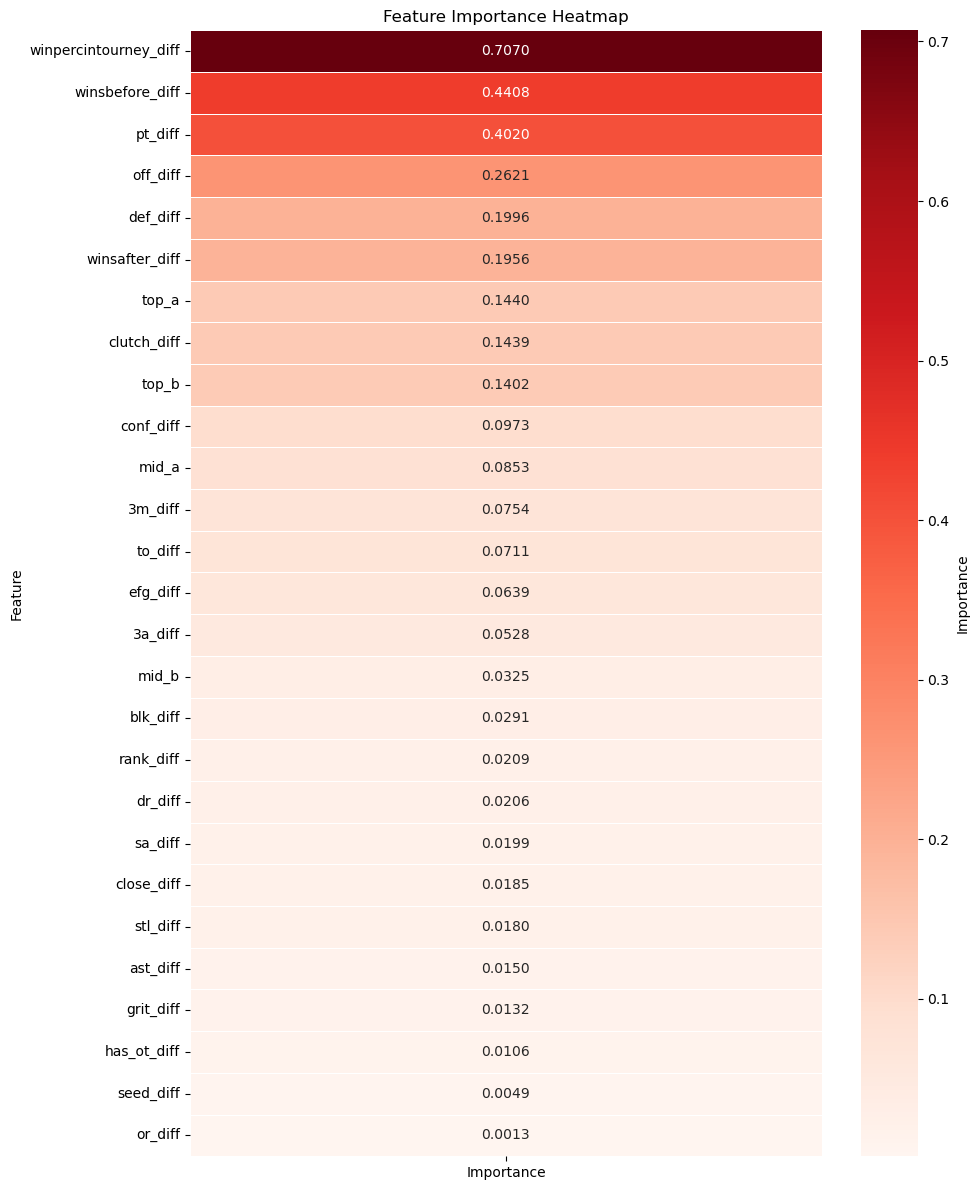

In [255]:
### Visualize as a heatmap

# DataFrame for plotting
df_imp = pd.DataFrame({
    'Feature': X_orig.columns,
    'Importance': importance_orig
}).sort_values('Importance', ascending=False)

# Set Feature as index
df_imp.set_index('Feature', inplace=True)

# Plot heatmap
plt.figure(figsize=(10,12))
sns.heatmap(
    df_imp,
    annot=True,
    cmap='Reds',
    cbar_kws={'label': 'Importance'},
    fmt='.4f',
    linewidths=0.5
)
plt.title('Feature Importance Heatmap')
plt.xlabel('')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##### Top 5 predictors of winning in March Madness are:
> ##### historical tournament performance from 2022-25
> ##### number of wins before day 100
> ##### point differential (points scored vs points allowed)
> ##### points scored
> ##### points allowed

##### As a reminder, all '_diff' metrics are differences in z-scores

##### Conceptually, pt is interrelated with off and def (separately)
##### Calculate Variance Inflation Factor to look for multicollinearity

### Variance Inflation Factor (VIF)

In [256]:
# Use the RFECV features
selected_features = X_orig.columns[rfecv_orig.support_]
X_selected = X_orig[selected_features]

# Add constant
X_vif = sm.add_constant(X_selected)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Sort by VIF desc
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
display(vif_data)

,Feature,VIF
0,pt_diff,1947.090202
1,off_diff,1071.176430
2,def_diff,833.060053
3,3a_diff,29.258388
4,3m_diff,27.624074
5,sa_diff,21.485820
6,efg_diff,15.568736
7,winsbefore_diff,15.166424
8,rank_diff,8.566071
9,or_diff,3.872474


##### Interpreting VIF
> ##### ~1 means no multicollinearity
> ##### > 5 moderate correlation
> ##### > 10 high multicollinearity (consider removing or combining)

##### As expected, pt, off, and def have extremely high VIF scores (800+)
##### We also see high scores for 3a, sa, 3m, winsbefore, and efg
> ##### 3M and SA are components of EFG
> ##### 3M would also be somewhat related with 3A
> ##### If these are all predictors for winning games, they may also be drivers of wins before day 100 (winsbefore)
> ##### Also drop rank_diff, since it should be accounted for within winsbefore and winsafter
> > ##### A team that has higher wins will be ranked higher within their conference. It'd be rare for a team to do really well against out of division teams and poorly against teams within their division
> > ##### In addition, rank_diff has a moderately high VIF (8.5) but low importance (0.02)

### Model Revisions

#### Based on the RFECV and VIF results:
> ##### Keep: pt_diff, efg_diff
> > ##### Correlated with other metrics, but those will be removed. More important predictors
> ##### Drop due to high VIF: off_diff, def_diff
> ##### Drop due to high VIF and low importance: 3m_diff, 3a_diff, sa_diff
> ##### Drop due to low importance (<0.02): dr_diff, close_diff, stl_diff, ast_diff, grit_diff, has_ot_diff, or_diff
> > ##### As of now, 2026 Seeds have not yet been released. Keeping in due to anticipated effect, but as of now, they rank low

In [257]:
X_clean = X_orig.copy()
X_clean = X_clean.drop(
    ['off_diff','def_diff',
     '3m_diff','3a_diff','sa_diff',
     'dr_diff','close_diff','stl_diff','ast_diff','grit_diff','has_ot_diff','or_diff', 'rank_diff'],axis=1)
X_clean.head()

,top_a,mid_a,top_b,mid_b,efg_diff,pt_diff,winsbefore_diff,winsafter_diff,clutch_diff,to_diff,blk_diff,seed_diff,conf_diff,winpercintourney_diff
0,0,1,1,0,0.123279,-0.083709,-0.672530,-0.449176,-1.839140,0.307274,2.806270,0.0,6.0,0.500000
1,1,0,1,0,-0.223596,-0.134725,0.472988,-0.661514,0.916100,-0.153717,-3.281965,0.0,2.0,-0.500000
2,0,0,0,1,0.953422,0.378520,-0.174259,0.757985,0.864850,-0.540938,-2.023982,0.0,-3.0,0.666667
3,0,1,0,0,-1.008504,-0.062424,0.015918,0.898353,0.971621,0.411605,1.275345,0.0,-3.0,-0.500000
4,1,0,1,0,-1.947198,-0.739062,0.248319,-1.065773,0.000000,1.177091,1.713927,9.0,24.0,0.750000


In [258]:
X_clean.columns

Index(['top_a', 'mid_a', 'top_b', 'mid_b', 'efg_diff', 'pt_diff',
       'winsbefore_diff', 'winsafter_diff', 'clutch_diff', 'to_diff',
       'blk_diff', 'seed_diff', 'conf_diff', 'winpercintourney_diff'],
      dtype='object')

#### Quick check RFECV and VIF

In [259]:
### Define y and X
y = df_all['team_a_win'].astype(int)
X_pruned = X_clean.copy()

# Build model
logreg = LogisticRegression(max_iter=500)

# Run RFECV
rfecv_pruned = RFECV(estimator=logreg, cv=5, scoring = 'neg_log_loss')
rfecv_pruned = rfecv_pruned.fit(X_pruned,y)

In [260]:
# Output selected features
print('Selected Features:')
print(X_pruned.columns[rfecv_pruned.support_])

print('\nFeature rankings:')
print(rfecv_pruned.ranking_)

Selected Features:
Index(['top_a', 'mid_a', 'top_b', 'mid_b', 'efg_diff', 'pt_diff',
       'winsbefore_diff', 'winsafter_diff', 'clutch_diff', 'to_diff',
       'blk_diff', 'conf_diff', 'winpercintourney_diff'],
      dtype='object')

Feature rankings:
[1 1 1 1 1 1 1 1 1 1 1 2 1 1]


In [261]:
# Absolute logistic regression coefficients (importance)
importance_pruned = np.abs(rfecv_pruned.estimator_.coef_[0])

# Associate with each feature
feature_importance_pruned = list(zip(X_pruned.columns[rfecv_pruned.support_], importance_pruned))

# Sort by importance
feature_importance_pruned_sorted = sorted(feature_importance_pruned, key=lambda x: -x[1])

# Display
for feature, score in feature_importance_pruned_sorted:
    print(f"{feature:25s} {score:.4f}")

winpercintourney_diff     0.7288
pt_diff                   0.6998
winsbefore_diff           0.3099
winsafter_diff            0.1975
clutch_diff               0.1486
top_a                     0.1427
top_b                     0.1376
mid_a                     0.1089
conf_diff                 0.1035
mid_b                     0.0604
efg_diff                  0.0511
to_diff                   0.0458
blk_diff                  0.0350


In [262]:
### Export for XGBoost comparison
importance_table = pd.DataFrame({
    'Feature_pruned': X_pruned.columns[rfecv_pruned.support_],
    'Importance_pruned': importance_pruned
}).sort_values('Importance_pruned', ascending=False)

importance_table.to_csv('pruned_importance.csv', index=False)

In [263]:
# Use the RFECV features
selected_features = X_pruned.columns[rfecv_pruned.support_]
X_selected = X_pruned[selected_features]

# Add constant
X_vif = sm.add_constant(X_selected)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Sort by VIF desc
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
display(vif_data)

,Feature,VIF
0,pt_diff,9.742997
1,winsbefore_diff,8.136347
2,winsafter_diff,2.602896
3,efg_diff,2.173764
4,const,2.073873
5,top_a,1.820287
6,top_b,1.819427
7,to_diff,1.453362
8,conf_diff,1.441123
9,mid_a,1.421839


##### seed_diff was given a rank of 2 and dropped from selected features
##### No results with < 0.02 importance or > 10 VIF
##### pt_diff and winsbefore_diff still have moderately high VIF, but will keep in, as they're important drivers

### Logistic Regression with Pruned Features

In [264]:
### Define y and X
y = df_all['team_a_win'].astype(bool)
X = X_selected

# Check for and remove columns with zero variance
X_var = X.var()
zero_var_cols = X_var[X_var == 0].index
X = X.drop(columns=zero_var_cols, errors='ignore')

# Add intercept
X = sm.add_constant(X)

In [265]:
### Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [266]:
### Run the model
logit_model=sm.Logit(y_train,X_train)
result=logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.470583
         Iterations 7
                           Results: Logit
Model:                Logit             Method:            MLE       
Dependent Variable:   team_a_win        Pseudo R-squared:  0.321     
Date:                 2026-03-16 12:35  AIC:               29030.9838
No. Observations:     30816             BIC:               29147.6849
Df Model:             13                Log-Likelihood:    -14501.   
Df Residuals:         30802             LL-Null:           -21360.   
Converged:            1.0000            LLR p-value:       0.0000    
No. Iterations:       7.0000            Scale:             1.0000    
---------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------------
const                  0.0228   0.0200  1.1412 0.2538 -0.0163  0.0619
top_a           

### Evaluating model on Test Data

In [267]:
### Predict on the test data
# Predicted probabilities
y_pred_prob = result.predict(X_test)

# Convert probabilities to 0/1 predictions for accuracy
y_pred = (y_pred_prob > 0.5).astype(int)

#### Accuracy, Log Loss, ROC AUC

In [268]:
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_pred_prob))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.7723177103051412
Log Loss: 0.4660048109982525
ROC AUC: 0.8575711575083107


##### ~77% games are correctly predicted with a 0.5 cutoff
##### 0.47 Log Loss suggests good calibration (< 0.5); method penalizes wrong predictions heavily
##### 0.86 ROC AUC is closer to 1.0 (perfect separation) than 0.5 (random guessing)

In [269]:
# Brier score for Kaggle
print("Brier Score:", brier_score_loss(y_test, y_pred_prob))

Brier Score: 0.15406959121605243


In [270]:
# Confusion matrix and Classification Report

confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)
# 5033 True Negatives; 1559 False Negatives
# 5167 True Positives; 1448 False Positives


print(classification_report(y_test, y_pred))
# 77-78% Precision: True Positives / TP + FP
# 76-78% Recall: True Positives / TP + FN
# 77% F1-Score: 2 * (Precision * Recall) / (Precision + Recall)

[[5033 1559]
 [1448 5167]]
              precision    recall  f1-score   support

       False       0.78      0.76      0.77      6592
        True       0.77      0.78      0.77      6615

    accuracy                           0.77     13207
   macro avg       0.77      0.77      0.77     13207
weighted avg       0.77      0.77      0.77     13207



##### False negatives are balanced with false positives, meaning model isn't biased toward over-predicting wins or losses; no systematic over/under-confidence
> ##### 1448 False Negatives / 1559 False Positives

##### Balanced across False/True classes, no major bias toward predicting favorites incorrectly
> ##### 0.77-0.78 score across metrics for both False and True

##### F1 around 0.77 aligns with the previously determined accuracy score

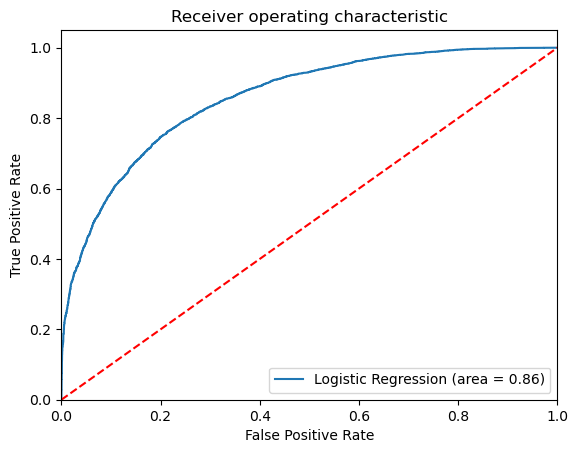

In [271]:
### PLotting the ROC AUC

# ROC AUC
logit_roc_auc = roc_auc_score(y_test, y_pred_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

#### Calibration Plot

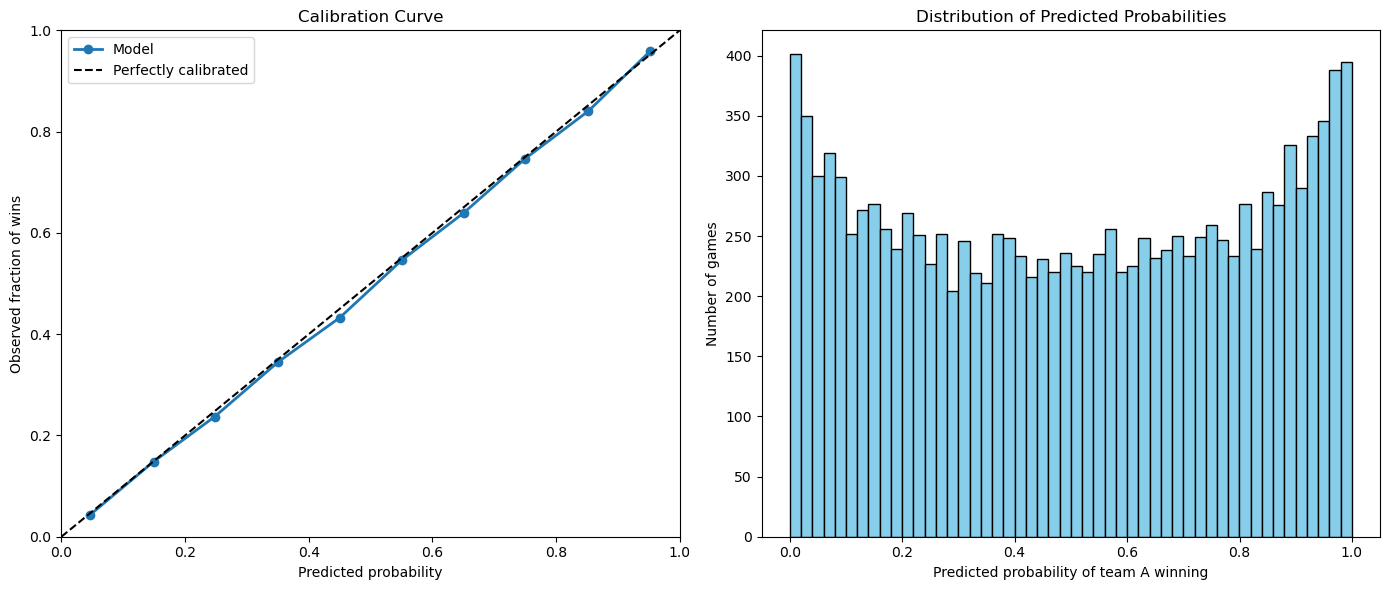

In [272]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

# Create figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Calibration Curve
ax[0].plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
ax[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax[0].set_xlabel('Predicted probability')
ax[0].set_ylabel('Observed fraction of wins')
ax[0].set_title('Calibration Curve')
ax[0].legend()
ax[0].set_xlim([0, 1])
ax[0].set_ylim([0, 1])

# Distribution of predicted probabilities
ax[1].hist(y_pred_prob, bins=50, color='skyblue', edgecolor='k')
ax[1].set_xlabel('Predicted probability of team A winning')
ax[1].set_ylabel('Number of games')
ax[1].set_title('Distribution of Predicted Probabilities')

plt.tight_layout()
plt.show()

##### Interpreting the Calibration Curve:
> ##### Points near diagonal means probabilities match actual outcomes
> ##### Points below: model overconfident
> ##### Points above: model is underconfident

##### Interpreting the Probability Distribution
> ##### Spread between 0.1 to 0.9 means model is making meaningful distinctions between favorites and underdogs
> ##### Clustering around 0.5 means model is indecisive

#####

### Print the results

In [273]:
SampleSubmission = pd.read_csv("SampleSubmissionStage2.csv", sep=',', index_col=None)
team_a_2026 = pd.read_csv("team_a_2026.csv", sep=',', index_col=None)
team_b_2026 = pd.read_csv("team_b_2026.csv", sep=',', index_col=None)

##### Remake the dataset for 2026 data

In [274]:
submission = pd.concat([SampleSubmission['ID'], SampleSubmission['ID'].str.split('_', expand=True).rename(
    columns={0:'season', 1:'team_a', 2:'team_b'})], axis=1)
submission.head()

,ID,season,team_a,team_b
0,2026_1101_1102,2026,1101,1102
1,2026_1101_1103,2026,1101,1103
2,2026_1101_1104,2026,1101,1104
3,2026_1101_1105,2026,1101,1105
4,2026_1101_1106,2026,1101,1106


In [275]:
submission[['team_a', 'team_b', 'season']] = submission[['team_a','team_b','season']].astype(int)

In [276]:
pred1 = pd.merge(submission, team_a_2026, how='left', left_on=['season','team_a'], right_on=['Season','team_a']).drop(['Season'], axis=1)
pred2 = pd.merge(pred1, team_b_2026, how='left', left_on=['team_b','season'], right_on=['team_b','Season']).drop(['Season'], axis=1)

In [277]:
team_a_2026.head()

,team_a,Season,conf_a,z.efg_a,z.sa_a,z.pt_a,rank_a,top_a,mid_a,bot_a,z.winsbefore_a,z.winsafter_a,z.clutch_a,z.close_a,z.grit_a,z.has_ot_a,z.off_a,z.def_a,z.ast_a,z.to_a,z.stl_a,z.blk_a,z.or_a,z.dr_a,z.3m_a,z.3a_a,seed_strength_a,M_W_a,conf_strength_a,winpercintourney_a
0,1101,2026,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.300330,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.000000
1,1102,2026,mwc,-0.175115,-1.203686,-2.076803,20,0,0,1,-1.763332,-1.976930,-1.203073,-1.285651,0.000000,-1.178771,-1.018115,1.379356,-0.504111,0.085482,-0.970406,-0.878070,-1.941526,-1.012617,-0.245519,-0.007985,17.0,M,26.0,0.000000
2,1103,2026,mac,2.088606,1.858487,1.446969,4,0,1,0,1.316575,2.119790,0.512228,-0.948143,0.000000,-1.178771,2.058478,0.616427,2.015763,-0.916825,-0.042117,-0.357421,0.220382,1.026064,2.289566,1.692553,5.0,M,16.0,0.000000
3,1104,2026,sec,1.132784,3.593371,0.973787,11,0,0,1,1.010385,1.095610,1.247357,0.064381,1.252030,-0.451174,2.646483,1.889455,1.244654,-1.294037,-0.506262,1.920422,0.580700,2.029960,3.329134,3.447199,13.0,M,31.0,0.554167
4,1105,2026,swac,0.404848,-1.220059,-0.259354,3,1,0,0,-0.093441,0.299025,0.022142,-0.475631,1.252030,-0.402667,0.175851,0.526532,-0.910779,-0.904610,-0.641934,-0.504938,-0.853365,-0.154929,-0.302665,-0.752100,17.0,M,4.0,0.000000


In [278]:
### Calculate differences
pred2['efg_diff'] = pred2['z.efg_a'] - pred2['z.efg_b']
pred2['sa_diff'] = pred2['z.sa_a'] - pred2['z.sa_b']
pred2['pt_diff'] = pred2['z.pt_a'] - pred2['z.pt_b']
pred2['rank_diff'] = pred2['rank_a'] - pred2['rank_b']
pred2['winsbefore_diff'] = pred2['z.winsbefore_a'] - pred2['z.winsbefore_b']
pred2['winsafter_diff'] = pred2['z.winsafter_a'] - pred2['z.winsafter_b']
pred2['clutch_diff'] = pred2['z.clutch_a'] - pred2['z.clutch_b']
pred2['close_diff'] = pred2['z.close_a'] - pred2['z.close_b']
pred2['grit_diff'] = pred2['z.grit_a'] - pred2['z.grit_b']
pred2['has_ot_diff'] = pred2['z.has_ot_a'] - pred2['z.has_ot_b']
pred2['off_diff'] = pred2['z.off_a'] - pred2['z.off_b']
pred2['def_diff'] = pred2['z.def_a'] - pred2['z.def_b']
pred2['ast_diff'] = pred2['z.ast_a'] - pred2['z.ast_b']
pred2['to_diff'] = pred2['z.to_a'] - pred2['z.to_b']
pred2['stl_diff'] = pred2['z.stl_a'] - pred2['z.stl_b']
pred2['blk_diff'] = pred2['z.blk_a'] - pred2['z.blk_b']
pred2['or_diff'] = pred2['z.or_a'] - pred2['z.or_b']
pred2['dr_diff'] = pred2['z.dr_a'] - pred2['z.dr_b']
pred2['3m_diff'] = pred2['z.3m_a'] - pred2['z.3m_b']
pred2['3a_diff'] = pred2['z.3a_a'] - pred2['z.3a_b']
pred2['winpercintourney_diff'] = pred2['winpercintourney_a'] - pred2['winpercintourney_b']
pred2['seed_diff'] = pred2['seed_strength_a'] - pred2['seed_strength_b']
pred2['conf_diff'] = pred2['conf_strength_a'] - pred2['conf_strength_b']

In [279]:
pred2.head()

,ID,season,team_a,team_b,conf_a,z.efg_a,z.sa_a,z.pt_a,rank_a,top_a,mid_a,bot_a,z.winsbefore_a,z.winsafter_a,z.clutch_a,z.close_a,z.grit_a,z.has_ot_a,z.off_a,z.def_a,z.ast_a,z.to_a,z.stl_a,z.blk_a,z.or_a,z.dr_a,z.3m_a,z.3a_a,seed_strength_a,M_W_a,conf_strength_a,winpercintourney_a,conf_b,z.efg_b,z.sa_b,z.pt_b,rank_b,top_b,mid_b,bot_b,z.winsbefore_b,z.winsafter_b,z.clutch_b,z.close_b,z.grit_b,z.has_ot_b,z.off_b,z.def_b,z.ast_b,z.to_b,z.stl_b,z.blk_b,z.or_b,z.dr_b,z.3m_b,z.3a_b,seed_strength_b,M_W_b,conf_strength_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff
0,2026_1101_1102,2026,1101,1102,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mwc,-0.175115,-1.203686,-2.076803,20,0,0,1,-1.763332,-1.976930,-1.203073,-1.285651,0.00000,-1.178771,-1.018115,1.379356,-0.504111,0.085482,-0.970406,-0.878070,-1.941526,-1.012617,-0.245519,-0.007985,17.0,M,26.0,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0
1,2026_1101_1103,2026,1101,1103,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mac,2.088606,1.858487,1.446969,4,0,1,0,1.316575,2.119790,0.512228,-0.948143,0.00000,-1.178771,2.058478,0.616427,2.015763,-0.916825,-0.042117,-0.357421,0.220382,1.026064,2.289566,1.692553,5.0,M,16.0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0
2,2026_1101_1104,2026,1101,1104,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,sec,1.132784,3.593371,0.973787,11,0,0,1,1.010385,1.095610,1.247357,0.064381,1.25203,-0.451174,2.646483,1.889455,1.244654,-1.294037,-0.506262,1.920422,0.580700,2.029960,3.329134,3.447199,13.0,M,31.0,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0
3,2026_1101_1105,2026,1101,1105,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,0.404848,-1.220059,-0.259354,3,1,0,0,-0.093441,0.299025,0.022142,-0.475631,1.25203,-0.402667,0.175851,0.526532,-0.910779,-0.904610,-0.641934,-0.504938,-0.853365,-0.154929,-0.302665,-0.752100,17.0,M,4.0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0
4,2026_1101_1106,2026,1101,1106,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,-0.275941,0.606209,-0.668243,16,0,0,1,-1.117280,-0.440660,-0.794668,-0.545311,0.00000,-1.178771,0.193995,1.053695,-0.686672,-0.210030,0.312613,0.578909,0.714367,-0.350494,0.235141,0.433855,17.0,M,4.0,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.32856

In [280]:
pred3 = pred2[['ID','season','team_a','team_b','top_a','mid_a','bot_a','winpercintourney_a',
                          'top_b','mid_b','bot_b','winpercintourney_b',
                          'efg_diff', 'sa_diff', 'pt_diff', 'rank_diff', 'winsbefore_diff', 'winsafter_diff',
                          'clutch_diff', 'close_diff', 'grit_diff', 'has_ot_diff', 'off_diff', 'def_diff', 'ast_diff',
                          'to_diff', 'stl_diff', 'blk_diff', 'or_diff', 'dr_diff', '3m_diff', '3a_diff',
                          'winpercintourney_diff', 'seed_diff', 'conf_diff']].copy()

display(pred3.head(), pred3.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0


(132133, 35)

In [281]:
pred3_vars = pred3[list(X_selected.columns)].copy()
pred3_vars.head()

,top_a,mid_a,top_b,mid_b,efg_diff,pt_diff,winsbefore_diff,winsafter_diff,clutch_diff,to_diff,blk_diff,conf_diff,winpercintourney_diff
0,0,0,0,0,0.012355,1.423609,1.069862,1.638688,1.225215,0.033051,0.199582,-5.0,0.000000
1,0,0,0,1,-2.251365,-2.100164,-2.010044,-2.458032,-0.490086,1.035358,-0.321067,5.0,0.000000
2,0,0,0,0,-1.295543,-1.626981,-1.703855,-1.433852,-1.225215,1.412570,-2.598910,-10.0,-0.554167
3,0,0,1,0,-0.567607,-0.393840,-0.600029,-0.637268,0.000000,1.023143,-0.173550,17.0,0.000000
4,0,0,0,0,0.113182,0.015048,0.423810,0.102418,0.816810,0.328563,-1.257397,17.0,-0.125000


In [282]:
# Check for NaNs
pred3_vars.isnull().sum()

top_a                      0
mid_a                      0
top_b                      0
mid_b                      0
efg_diff                   0
pt_diff                    0
winsbefore_diff            0
winsafter_diff             0
clutch_diff                0
to_diff                    0
blk_diff                   0
conf_diff                  0
winpercintourney_diff    726
dtype: int64

In [283]:
# Set all NaN to 0
pred3_vars = pred3_vars.fillna(0)
pred3_vars.isnull().sum()

top_a                    0
mid_a                    0
top_b                    0
mid_b                    0
efg_diff                 0
pt_diff                  0
winsbefore_diff          0
winsafter_diff           0
clutch_diff              0
to_diff                  0
blk_diff                 0
conf_diff                0
winpercintourney_diff    0
dtype: int64

##### Predict 2026 results

In [284]:
# Add intercept

X_2026 = pred3_vars
X_2026 = sm.add_constant(X_2026, has_constant='add')

In [285]:
# Predict probabilities
y_pred_prob = result.predict(X_2026)

In [286]:
pred3['pred'] = y_pred_prob

In [287]:
display(pred3.head(), pred3.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881


(132133, 36)

##### Create Kaggle submission file

In [288]:
pred3[['ID', 'pred']].to_csv('kaggle_submission_pruned.csv', index=False)

In [289]:
pred3.to_csv('2026_full_prediction.csv', index=False)

##### Merge with Team Name data frame to more easily fill out brackets

In [290]:
M_Teams = pd.read_csv("MTeams.csv", sep=',', index_col=None)
W_Teams = pd.read_csv("WTeams.csv", sep=',', index_col=None)
Teams = pd.concat([M_Teams,W_Teams])

Teams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014.0,2026.0
1,1102,Air Force,1985.0,2026.0
2,1103,Akron,1985.0,2026.0
3,1104,Alabama,1985.0,2026.0
4,1105,Alabama A&M,2000.0,2026.0


In [291]:
result1 = pred3.merge(Teams, how='left', left_on='team_a', right_on='TeamID').rename(
    columns={'TeamName':'team_a_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
result2 = result1.merge(Teams, how='left', left_on='team_b', right_on='TeamID').rename(
    columns={'TeamName':'team_b_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
display(result2.head(), result2.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred,team_a_name,team_b_name
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232,Abilene Chr,Air Force
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033,Abilene Chr,Akron
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631,Abilene Chr,Alabama
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535,Abilene Chr,Alabama A&M
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881,Abilene Chr,Alabama St


(132133, 38)

In [292]:
results_for_bracket = result2[['team_a','team_a_name','team_b','team_b_name','pred']]
results_for_bracket.to_csv('bracket_submission_pruned.csv', index=False)

### Comparison with Original Model

##### Model performance is relatively similar
> ##### Confusion matrix and Classification report have similar numbers and balance
> ##### ROC AUC is 0.86 for both models
> ##### Calibration curve and Probability distribution look similar

#### Are predicted outcomes different?

In [293]:
### Pruned model
pruned_model = pred3[['ID', 'pred']].copy()
pruned_model['win_pruned'] = pruned_model.apply(lambda pruned_model: ('Win' if pruned_model['pred'] > 0.5 else 'Loss'), axis=1)
pruned_model = pruned_model.rename(columns={'pred':'pred_pruned'})
display(pruned_model.head(), pruned_model.shape)

,ID,pred_pruned,win_pruned
0,2026_1101_1102,0.790232,Win
1,2026_1101_1103,0.099033,Loss
2,2026_1101_1104,0.022631,Loss
3,2026_1101_1105,0.788535,Win
4,2026_1101_1106,0.877881,Win


(132133, 3)

In [294]:
original_model = pd.read_csv("kaggle_submission.csv", sep=',', index_col=None)

In [295]:
original_model['win_original'] = original_model.apply(lambda original_model: ('Win' if original_model['pred'] > 0.5 else 'Loss'), axis=1)
original_model = original_model.rename(columns={'pred':'pred_original'})
display(original_model.head(), original_model.shape)

,ID,pred_original,win_original
0,2026_1101_1102,0.158974,Loss
1,2026_1101_1103,0.829076,Win
2,2026_1101_1104,0.000138,Loss
3,2026_1101_1105,0.999982,Win
4,2026_1101_1106,0.999990,Win


(132133, 3)

In [296]:
model_comp = pruned_model.merge(original_model,how='inner',on='ID')
display(model_comp.head(),model_comp.shape)

,ID,pred_pruned,win_pruned,pred_original,win_original
0,2026_1101_1102,0.790232,Win,0.158974,Loss
1,2026_1101_1103,0.099033,Loss,0.829076,Win
2,2026_1101_1104,0.022631,Loss,0.000138,Loss
3,2026_1101_1105,0.788535,Win,0.999982,Win
4,2026_1101_1106,0.877881,Win,0.999990,Win


(132133, 5)

In [297]:
model_comp['pred_diff'] = model_comp['pred_pruned'] - model_comp['pred_original']
model_comp['flip'] = (model_comp['pred_pruned'] > 0.5) != (model_comp['pred_original'] > 0.5)
display(model_comp.head(),model_comp.shape)

,ID,pred_pruned,win_pruned,pred_original,win_original,pred_diff,flip
0,2026_1101_1102,0.790232,Win,0.158974,Loss,0.631258,True
1,2026_1101_1103,0.099033,Loss,0.829076,Win,-0.730043,True
2,2026_1101_1104,0.022631,Loss,0.000138,Loss,0.022493,False
3,2026_1101_1105,0.788535,Win,0.999982,Win,-0.211446,False
4,2026_1101_1106,0.877881,Win,0.999990,Win,-0.122109,False


(132133, 7)

In [298]:
print('# of matchups with different predictions:', sum(model_comp['flip']))
print('% difference:', round(sum(model_comp['flip'])/len(model_comp)*100,0))

# of matchups with different predictions: 20052
% difference: 15.0


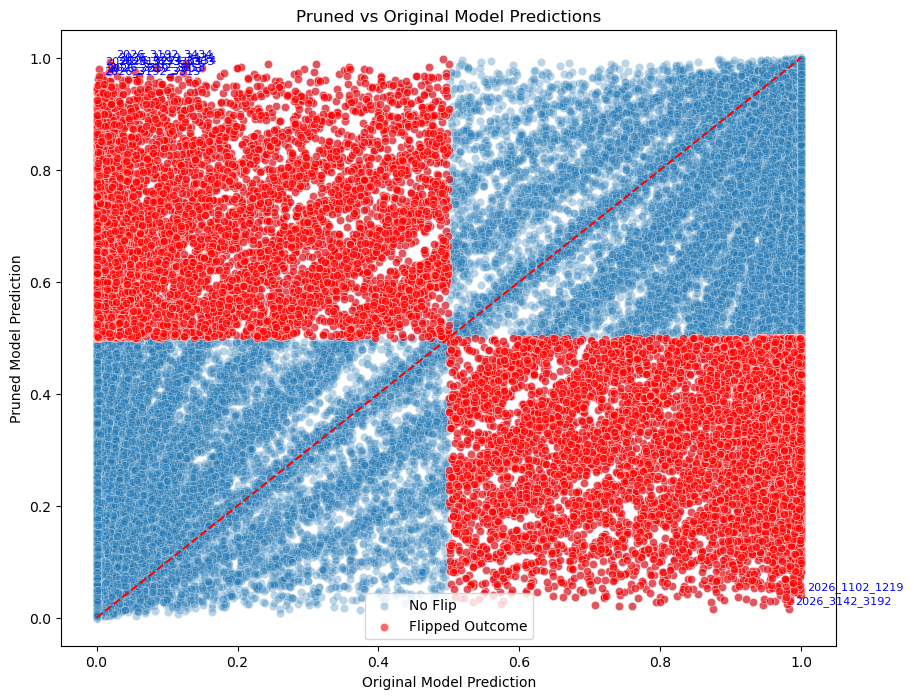

In [299]:
# Identify largest flips
top_flips = model_comp.loc[model_comp['flip']].copy()
top_flips['abs_diff'] = top_flips['pred_diff'].abs()
top_flips = top_flips.sort_values('abs_diff', ascending=False).head(10)

# Scatterplot
plt.figure(figsize=(10,8))
sns.scatterplot(
    x='pred_original',
    y='pred_pruned',
    data=model_comp,
    alpha=0.3,
    label='No Flip'
)
sns.scatterplot(
   x='pred_original',
    y='pred_pruned',
    data=model_comp[model_comp['flip']],
    color='red',
    alpha=0.6,
    label='Flipped Outcome'
)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('Original Model Prediction')
plt.ylabel('Pruned Model Prediction')
plt.title('Pruned vs Original Model Predictions')

# Annotate largest flips
for idx, row in top_flips.iterrows():
    plt.text(
        row['pred_original']+0.01,
        row['pred_pruned']+0.01,
        row['ID'],
        fontsize=8,
        color='blue'
    )

##### Pruning didn't substantially change outcomes - only 14% of matchups were predited differently
##### However, where they did predict differently, the swings are huge
##### Models are highly confident in opposite directions; pruning changed the models' decision boundary substantially
##### Flips driven by features that were removed or downweighted
> ##### high_VIF features like off_diff, def_diff, components of pt_diff


In [300]:
### Comparing importance

# Original model
selected_orig = X_orig.columns[rfecv_orig.support_]
importance_orig = np.abs(rfecv_orig.estimator_.coef_[0])

orig_importance = pd.DataFrame({
    'Feature': selected_orig,
    'Importance_Original': importance_orig
})

orig_importance = orig_importance[orig_importance['Feature'] != 'const']

# Pruned model (from RFECV)
selected_pruned = X_pruned.columns[rfecv_pruned.support_]
importance_pruned = np.abs(rfecv_pruned.estimator_.coef_[0])

pruned_importance = pd.DataFrame({
    'Feature': X_clean.columns[rfecv_pruned.support_],
    'Importance_Pruned': np.abs(rfecv_pruned.estimator_.coef_[0])
})

#Merge
importance_comparison = pd.merge(
    orig_importance,
    pruned_importance,
    on='Feature',
    how='outer'
).fillna(0)

# Calculate Difference
importance_comparison['Diff'] = importance_comparison['Importance_Pruned'] - importance_comparison['Importance_Original']

display(importance_comparison.sort_values('Importance_Pruned', ascending=False))

,Feature,Importance_Original,Importance_Pruned,Diff
24,winpercintourney_diff,0.706989,0.728791,0.021802
16,pt_diff,0.401962,0.699831,0.297869
26,winsbefore_diff,0.440817,0.309867,-0.130950
25,winsafter_diff,0.195552,0.197483,0.001931
5,clutch_diff,0.143890,0.148566,0.004676
22,top_a,0.144041,0.142749,-0.001292
23,top_b,0.140204,0.137561,-0.002644
12,mid_a,0.085316,0.108943,0.023628
6,conf_diff,0.097341,0.103512,0.006171
13,mid_b,0.032496,0.060397,0.027901


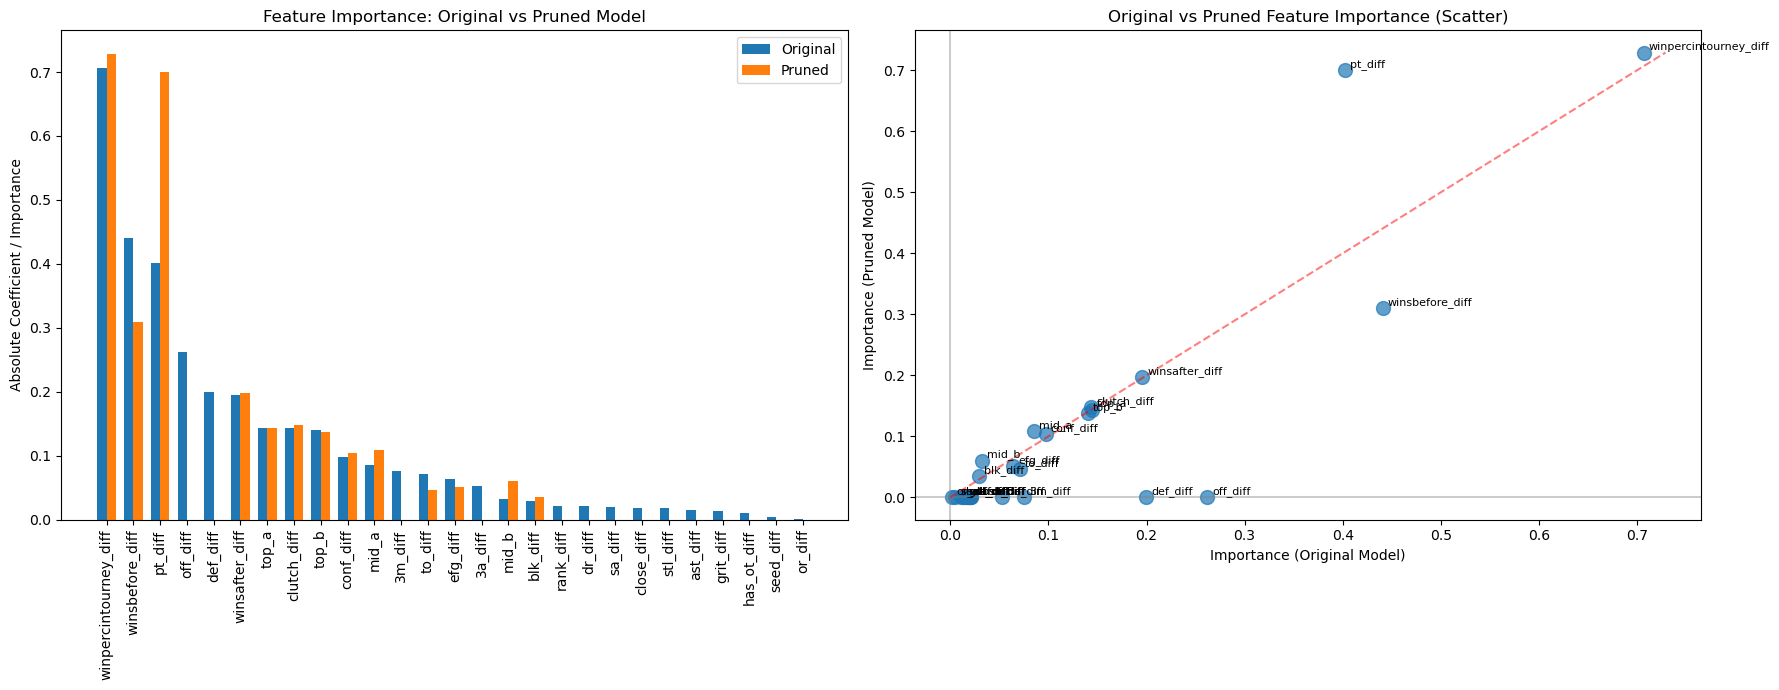

In [301]:
### Plot differences

# Sort by original importance
importance_comparison_sorted = importance_comparison.sort_values(
    by='Importance_Original', ascending=False
)

### Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

### Bar Chart
ax = axes[0]

bar_width = 0.35
x = np.arange(len(importance_comparison_sorted))

ax.bar(x - bar_width/2, importance_comparison_sorted['Importance_Original'],
       width=bar_width, label='Original')
ax.bar(x + bar_width/2, importance_comparison_sorted['Importance_Pruned'],
       width=bar_width, label='Pruned')

ax.set_xticks(x)
ax.set_xticklabels(importance_comparison_sorted['Feature'], rotation=90)
ax.set_ylabel('Absolute Coefficient / Importance')
ax.set_title('Feature Importance: Original vs Pruned Model')
ax.legend()

### Scatterplot
ax = axes[1]

ax.scatter(
    importance_comparison['Importance_Original'],
    importance_comparison['Importance_Pruned'],
    s=100, alpha=0.7
)

# Annotate the points
for _, row in importance_comparison.iterrows():
    ax.text(
        row['Importance_Original'] + 0.005,
        row['Importance_Pruned'] + 0.005,
        row['Feature'],
        fontsize=8
    )

# Axes lines and diagonal
ax.axhline(0, color='gray', alpha=0.4)
ax.axvline(0, color='gray', alpha=0.4)

max_orig = importance_comparison['Importance_Original'].max()
max_pruned = importance_comparison['Importance_Pruned'].max()
line_max = max(max_orig, max_pruned)

ax.plot([0, line_max], [0, line_max], 'r--', alpha = 0.5)

ax.set_xlabel('Importance (Original Model)')
ax.set_ylabel('Importance (Pruned Model)')
ax.set_title('Original vs Pruned Feature Importance (Scatter)')

plt.tight_layout()
plt.show()

### Explaining the Flips

#### 'pt_diff' saw the largest increase in importance due to RCEFV
> ##### Removed correlated features (off_diff, def_diff, 3m_diff, sa_diff)
> ##### Assigned more predictive weight as it captures all the signal that was previously distributed over multiple correlated predictors
#####
#### Major drivers in full model saw some of the largest negative shifts
> ##### off_diff, def_diff, winsbefore_diff, 3m_diff, 3a_diff, to_diff
#####
#### Less important features (mid_b, mid_a, winpercintourney_diff) saw a bump in importance with a cleaner model
#####
#### Several features dropped entirely to help stabilize the model
> ##### Multicollinearity: off_diff, def_diff, 3m_diff, 3a_diff, sa_diff
> ##### Low/no predictive power: has_ot_diff, close_diff, dr_diff, stl_diff, grit_diff

### Conclusions
> #### The original model had redundant predictors, inflating variance and increasing sensitivity to small input changes
> #### By pruning, the model became cleaner, more stable, and less senstivite to noise